In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [3]:
def planar2d_maxwellian_ode(eta, y):
    psi, dpsi = y

    d2psi = (2.0 + np.exp(-psi)) / np.cos(eta)**2

    return [dpsi, d2psi]

In [87]:
# initial conditions
psi0 = -8
dpsi0 = 0

# plotting grid
x = np.linspace(1e-3, 10, 10000)
z = np.linspace(-5, 5, 100)

In [88]:
# solve problem
sol_pos = solve_ivp(
    planar2d_maxwellian_ode,
    (0,1.56),
    [psi0, dpsi0],
    rtol=1e-8,
    atol=1e-8
)

sol_neg = solve_ivp(
    planar2d_maxwellian_ode,
    (0,-1.56),
    [psi0, dpsi0],
    rtol=1e-8,
    atol=1e-8
)

eta = np.concatenate((sol_neg.t[::-1], sol_pos.t[1:]))
psi = np.concatenate((sol_neg.y[0][::-1], sol_pos.y[0][1:]))
    

/var/folders/6n/1_vggvts3ssfl9_6wlgcz7v00000gn/T/ipykernel_95614/3064754565.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


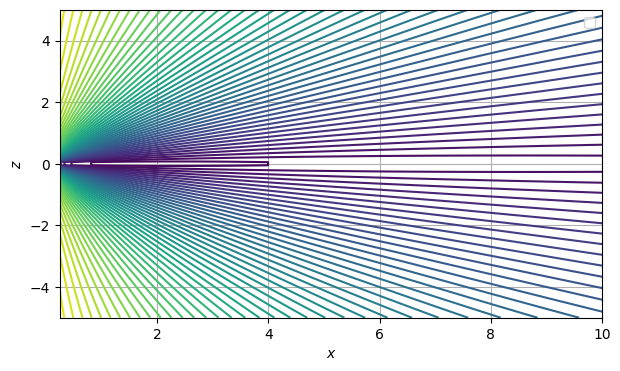

/var/folders/6n/1_vggvts3ssfl9_6wlgcz7v00000gn/T/ipykernel_95614/3064754565.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


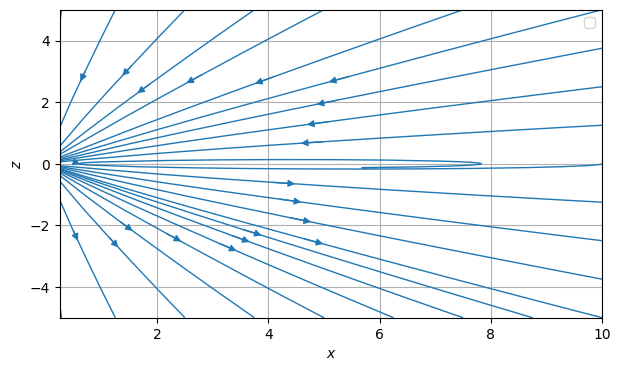

In [ ]:
# Plot
X,Z = np.meshgrid(x,z)
ETA = np.atan2(Z,X)

psi_interp = interp1d(
        eta,
        psi,
        kind='cubic',
        bounds_error=False,
        fill_value='extrapolate'
    )

PSI = psi_interp(ETA)

dx = x[1] - x[0]
dz = z[1] - z[0]
Ay = 2*np.log(X) + PSI

dAy_dz, dAy_dx = np.gradient(Ay, dz, dx)
Bx = -dAy_dz
Bz = dAy_dx

plt.figure(figsize=(7,4))
plt.contour(X, Z, Ay, levels = 50)
plt.xlim(0.25, x[-1])
plt.ylim(z[0], z[-1])
plt.xlabel(r'$x$')
plt.ylabel(r'$z$')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.streamplot(X, Z, Bx, Bz, linewidth = 1)
plt.xlim(0.25, x[-1])
plt.ylim(z[0], z[-1])
plt.xlabel(r'$x$')
plt.ylabel(r'$z$')
plt.grid(True)
plt.legend()
plt.show()